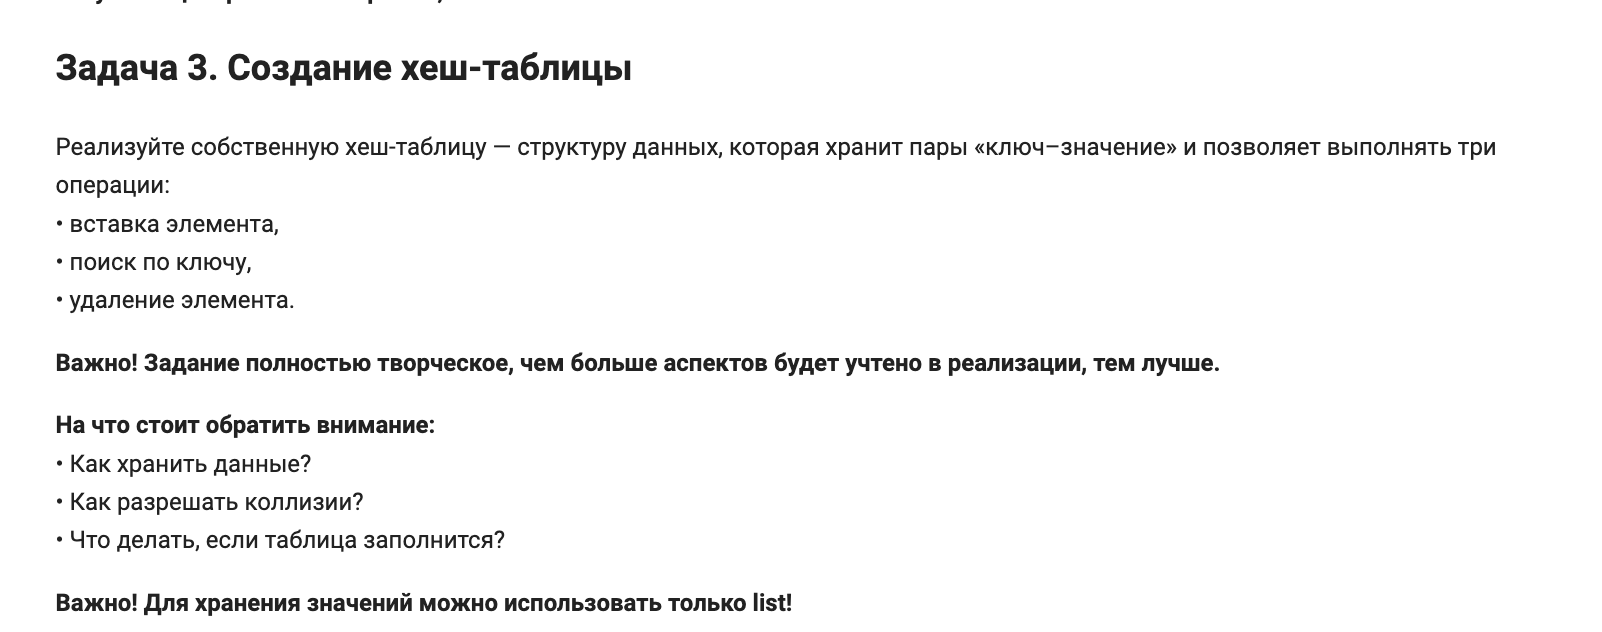

# Ход решения

Создаем список `buckets`, в котором будем хранить все элементы нашей хеш-таблицы. Каждый элемент этого списка — это отдельная корзина, которая тоже является списком. Внутри корзины уже будут лежать пары ключ-значение.

В начале задаем `capacity` — количество корзин в таблице, `size` — текущее количество элементов и `max_load` — максимальную заполненность таблицы. Я взял `max_load = 0.75`, то есть когда элементов становится больше 75% от количества корзин, таблицу будем увеличивать.

Дальше для любого ключа нужно понять, в какую корзину его положить. Для этого берем `hash(key)` и остаток от деления на `capacity`. За счет остатка мы всегда получаем индекс от 0 до `capacity - 1`, то есть существующую корзину. Hash используем базовый, который реализован в питоне.

При вставке сначала определяем корзину для ключа. После этого проходим по элементам этой корзины и проверяем, нет ли такого ключа уже. Если ключ уже существует, просто меняем его значение. Если ключ новый, добавляем новую пару в корзину и увеличиваем `size`.

Если два разных ключа получили один и тот же индекс, возникает коллизия(. Решать ее будем через separate chaining, самый просто в реализации метод, но при этом все еще достаточно эффективный (причем по времени он работает столько же, сколько квадратичный пробинг, например): просто храним несколько пар в одной корзине. Поэтому одна корзина может содержать как один элемент, так и несколько.

После добавления нового элемента проверяем отношение `size` к `capacity`. Если оно стало больше `max_load`, увеличиваем `capacity` в два раза и создаем новый список корзин. После этого все старые элементы нужно заново распределить по таблице, потому что индекс зависит от `capacity`, а значит после увеличения таблицы он для некоторых ключей изменится.

Поиск работает по той же логике: сначала по ключу определяем нужную корзину, а затем уже только внутри нее ищем пару с нужным ключом. Если нашли — возвращаем значение. Если такого ключа нет, выбрасываем `KeyError`.

Удаление почти такое же. Сначала находим нужную корзину, затем ищем там нужный ключ. Когда находим, удаляем эту пару из списка, уменьшаем `size` и возвращаем удаленное значение. Если ключа в таблице нет, снова выбрасываем `KeyError`.

Таким образом, мы не проходим каждый раз по всей таблице, а сразу переходим в нужную корзину. При хорошем распределении ключей в каждой корзине будет совсем немного элементов, поэтому вставка, поиск и удаление в среднем будут работать за константное время.

## Сложность алгоритма

Пусть `n` — количество элементов в хеш-таблице.

При хорошем распределении ключей элементы распределены по корзинам примерно равномерно, поэтому нужная корзина обычно содержит мало элементов.

| Операция | В среднем | В худшем случае |
| --- | ---: | ---: |
| Вставка | `O(1)` | `O(n)` |
| Поиск | `O(1)` | `O(n)` |
| Удаление | `O(1)` | `O(n)` |

Худший случай возникает, если много ключей попали в одну корзину: тогда приходится просматривать почти все элементы.

Изменение размера таблицы занимает `O(n)`, потому что элементы нужно заново распределить по новым корзинам. Но resize происходит не при каждой вставке, поэтому **амортизированная** сложность вставки остаётся `O(1)`.

### Память

Для хранения используются:

- внешний список корзин;
- списки внутри корзин;
- пары `[key, value]`.

При поддержании коэффициента заполнения не выше `0.75` число корзин остаётся одного порядка с числом элементов, поэтому дополнительная память:

`O(n)`.

# Реализация

Реализуем класс `HashTable`.

В качестве основной структуры хранения используются только списки. Словари и множества внутри реализации не используются.

Дополнительно реализуем автоматическое увеличение таблицы при заполнении более чем на `75%`.

In [2]:
class HashTable:
    def __init__(self, capacity=8):
        self.capacity = max(2, capacity)
        self.size = 0
        self.max_load = 0.75
        self.buckets = [[] for _ in range(self.capacity)]

    def _index(self, key):
        return hash(key) % self.capacity

    def _resize(self):
        old_buckets = self.buckets
        self.capacity *= 2
        self.buckets = [[] for _ in range(self.capacity)]

        for bucket in old_buckets:
            for key, value in bucket:
                self.buckets[self._index(key)].append([key, value])

    def insert(self, key, value):
        bucket = self.buckets[self._index(key)]

        for pair in bucket:
            if pair[0] == key:
                pair[1] = value
                return

        bucket.append([key, value])
        self.size += 1

        if self.size / self.capacity > self.max_load:
            self._resize()

    def search(self, key):
        bucket = self.buckets[self._index(key)]

        for pair in bucket:
            if pair[0] == key:
                return pair[1]

        raise KeyError(key)

    def delete(self, key):
        bucket = self.buckets[self._index(key)]

        for i in range(len(bucket)):
            if bucket[i][0] == key:
                value = bucket[i][1]
                bucket.pop(i)
                self.size -= 1
                return value

        raise KeyError(key)

    def __len__(self):
        return self.size

# Визуализация работы алгоритма

Рассмотрим таблицу с `capacity = 4`.

Для маленьких целых чисел можно считать, что `hash(x) = x`, поэтому индекс корзины:

```text
index = key % 4
```

Изначально:

```text
0: []
1: []
2: []
3: []
```

### Шаг 1. `insert(1, "A")`

```text
1 % 4 = 1
```

Получаем:

```text
0: []
1: [[1, "A"]]
2: []
3: []
```

### Шаг 2. `insert(5, "B")`

```text
5 % 4 = 1
```

Ключ `5` попадает в ту же корзину, что и `1`. Возникает коллизия:

```text
0: []
1: [[1, "A"], [5, "B"]]
2: []
3: []
```

Обе пары остаются в корзине — это и есть разрешение коллизии методом цепочек.

### Шаг 3. `insert(2, "C")`

```text
2 % 4 = 2
```

```text
0: []
1: [[1, "A"], [5, "B"]]
2: [[2, "C"]]
3: []
```

### Шаг 4. `search(5)`

Сначала вычисляем:

```text
5 % 4 = 1
```

Просматриваем только корзину `1`:

```text
[1, "A"] -> ключ не подходит
[5, "B"] -> нашли
```

Результат:

```text
"B"
```

### Шаг 5. `delete(1)`

Снова идём в корзину `1` и удаляем пару с ключом `1`:

```text
0: []
1: [[5, "B"]]
2: [[2, "C"]]
3: []
```

## Что происходит при заполнении таблицы

Если `capacity = 4`, то при трёх элементах:

```text
load factor = 3 / 4 = 0.75
```

Resize пока не нужен.

После вставки четвёртого элемента:

```text
load factor = 4 / 4 = 1.0
```

Это больше `0.75`, поэтому `capacity` увеличивается:

```text
4 -> 8
```

После этого для всех ключей заново вычисляется:

```text
hash(key) % 8
```

То есть элементы перераспределяются по новым корзинам. Это позволяет не допускать слишком длинных цепочек и сохранять операции близкими к `O(1)` в среднем.

# Тесты

Тесты проверяют:

- обычную вставку и поиск;
- обновление значения по существующему ключу;
- несколько коллизий в одной корзине;
- удаление элемента из цепочки;
- хранение значения `None`;
- ошибки при поиске и удалении отсутствующего ключа;
- автоматическое увеличение таблицы;
- корректность данных после нескольких resize.

In [3]:
table = HashTable()

table.insert("name", "Alice")
table.insert("age", 20)

assert table.search("name") == "Alice"
assert table.search("age") == 20
assert len(table) == 2

table.insert("name", "Bob")
assert table.search("name") == "Bob"
assert len(table) == 2

collision_table = HashTable(8)
collision_table.insert(1, "one")
collision_table.insert(9, "nine")
collision_table.insert(17, "seventeen")

assert len(collision_table.buckets[1]) == 3
assert collision_table.search(1) == "one"
assert collision_table.search(9) == "nine"
assert collision_table.search(17) == "seventeen"

assert collision_table.delete(9) == "nine"
assert collision_table.search(1) == "one"
assert collision_table.search(17) == "seventeen"
assert len(collision_table) == 2

table.insert("empty", None)
assert table.search("empty") is None

try:
    table.search("missing")
    raise AssertionError("Ожидался KeyError")
except KeyError:
    pass

try:
    table.delete("missing")
    raise AssertionError("Ожидался KeyError")
except KeyError:
    pass

large_table = HashTable(4)

for i in range(1000):
    large_table.insert(i, i * i)

assert large_table.capacity > 4
assert len(large_table) == 1000

for i in range(1000):
    assert large_table.search(i) == i * i

print("Все тесты пройдены")

Все тесты пройдены
